## Aim 

In this code, the Land Surface Temperature data (LST) using band 10 at the ward level are merged with the road characteristics and this using the LST computed with the method of Ermida et al. (2020).

In [1]:
from pathlib import Path

## import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import linregress, pearsonr
from sklearn.linear_model import LinearRegression

## Reading in the data

In [2]:
# Define the paths
BASE_DIR = Path.cwd().parents[1]
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
IMAGES_DIR = BASE_DIR / "images"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


### Land Surface Temperature

In [3]:
lst_path = PROCESSED_DIR /'lstermidasummer_bang.csv'
print(lst_path)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\lstermidasummer_bang.csv


In [4]:
df_lst_mean_summer = pd.read_csv(lst_path)

In [5]:
df_lst_mean_summer.head()

,system:index,Corporatio,mean,ward_id,ward_name,.geo
0,00000000000000000007,Central,37.101195,24,24 - Agaram,"{""type"":""GeometryCollection"",""geometries"":[{""t..."
1,00000000000000000009,Central,38.345464,11,11 - Old Baiyappanahalli,"{""type"":""Polygon"",""coordinates"":[[[77.63789444..."
2,00000000000000000015,Central,38.115046,41,41 - V.V Puram,"{""type"":""Polygon"",""coordinates"":[[[77.57363440..."
3,0000000000000000001a,Central,39.383769,51,51 - Old Guddadahalli,"{""type"":""GeometryCollection"",""geometries"":[{""t..."
4,0000000000000000002e,Central,37.982895,13,13 - Krishnaiahnapalya,"{""type"":""Polygon"",""coordinates"":[[[77.64552398..."


In [6]:
print(f"The minimum temperature is {df_lst_mean_summer['mean'].min()}.")
print(f"The maximum temperature is {df_lst_mean_summer['mean'].max()}.")

The minimum temperature is 35.15153817773115.
The maximum temperature is 41.64818002114797.


### Road density

In [7]:
road_density_path = PROCESSED_DIR /'results_bangalore_all_roads.csv'
df_road_density = pd.read_csv(road_density_path)

In [8]:
df_road_density.head()

,Unnamed: 0,ward_id,ward_name,Corporatio,street_length,street_density,area
0,0,25,25 - Vinayaka Layout,West,75687.559355,29390.911807,2.575203e+06
1,1,2,2 - Aerocity,North,124800.280922,12164.886655,1.025906e+07
2,2,3,3 - Chowdeshwari ward,North,102396.516478,15924.039220,6.430310e+06
3,3,15,15 - Ramamurthy Nagara,East,22700.859701,28293.603033,8.023319e+05
4,4,58,58 - Nagashettyhalli,North,25813.225031,27016.836493,9.554496e+05


In [9]:
merged = pd.merge(df_lst_mean_summer, df_road_density, on='ward_name')
merged.head()

,system:index,Corporatio_x,mean,ward_id_x,ward_name,.geo,Unnamed: 0,ward_id_y,Corporatio_y,street_length,street_density,area
0,00000000000000000007,Central,37.101195,24,24 - Agaram,"{""type"":""GeometryCollection"",""geometries"":[{""t...",7,24,Central,135628.586924,12281.620334,1.104322e+07
1,00000000000000000009,Central,38.345464,11,11 - Old Baiyappanahalli,"{""type"":""Polygon"",""coordinates"":[[[77.63789444...",9,11,Central,11072.345249,20184.036462,5.485694e+05
2,00000000000000000015,Central,38.115046,41,41 - V.V Puram,"{""type"":""Polygon"",""coordinates"":[[[77.57363440...",21,41,Central,42281.858139,39226.496243,1.077890e+06
3,0000000000000000001a,Central,39.383769,51,51 - Old Guddadahalli,"{""type"":""GeometryCollection"",""geometries"":[{""t...",26,51,Central,7924.842106,37447.552097,2.116251e+05
4,0000000000000000002e,Central,37.982895,13,13 - Krishnaiahnapalya,"{""type"":""Polygon"",""coordinates"":[[[77.64552398...",46,13,Central,31325.489794,26383.779772,1.187301e+06


Only retain the relevant variables and rename:

In [12]:
merged = merged[['ward_name', 'mean', 'ward_id_x', 'Corporatio_x', 'street_length', 'street_density', 'area']]
merged.head()

,ward_name,mean,ward_id_x,Corporatio_x,street_length,street_density,area
0,24 - Agaram,37.101195,24,Central,135628.586924,12281.620334,1.104322e+07
1,11 - Old Baiyappanahalli,38.345464,11,Central,11072.345249,20184.036462,5.485694e+05
2,41 - V.V Puram,38.115046,41,Central,42281.858139,39226.496243,1.077890e+06
3,51 - Old Guddadahalli,39.383769,51,Central,7924.842106,37447.552097,2.116251e+05
4,13 - Krishnaiahnapalya,37.982895,13,Central,31325.489794,26383.779772,1.187301e+06


In [13]:
# Rename the columns
merged = merged.rename(columns={
    'ward_id_x': 'ward_id',
    'Corporatio_x': 'Corporation',
    'mean': 'mean_lst'
})
merged.head()

,ward_name,mean_lst,ward_id,Corporation,street_length,street_density,area
0,24 - Agaram,37.101195,24,Central,135628.586924,12281.620334,1.104322e+07
1,11 - Old Baiyappanahalli,38.345464,11,Central,11072.345249,20184.036462,5.485694e+05
2,41 - V.V Puram,38.115046,41,Central,42281.858139,39226.496243,1.077890e+06
3,51 - Old Guddadahalli,39.383769,51,Central,7924.842106,37447.552097,2.116251e+05
4,13 - Krishnaiahnapalya,37.982895,13,Central,31325.489794,26383.779772,1.187301e+06


In [14]:
print(f'The mininim street density is {merged["street_density"].min()} metres or {merged["street_density"].min()/1000} km per square km.')
print(f'The maximimum street density is {merged["street_density"].max()} metres or {merged["street_density"].max()/1000} km per square km.')

The mininim street density is 9898.12631486204 metres or 9.89812631486204 km per square km.
The maximimum street density is 43516.131293869774 metres or 43.516131293869776 km per square km.


In [15]:
# index of min and max street density
idx_min = merged["street_density"].idxmin()
idx_max = merged["street_density"].idxmax()

In [16]:
# ward names
ward_min = merged.loc[idx_min, "ward_name"]
ward_max = merged.loc[idx_max, "ward_name"]

In [17]:
print(f' The ward with the minimum street density is {ward_min} and the maximum street density is {ward_max}.')

 The ward with the minimum street density is 27 - Vibhootipura and the maximum street density is 53 - Rayapuram.


#### Street density

In [18]:
fig_path = IMAGES_DIR / 'regression_bangalore_street_density_ermida.png'

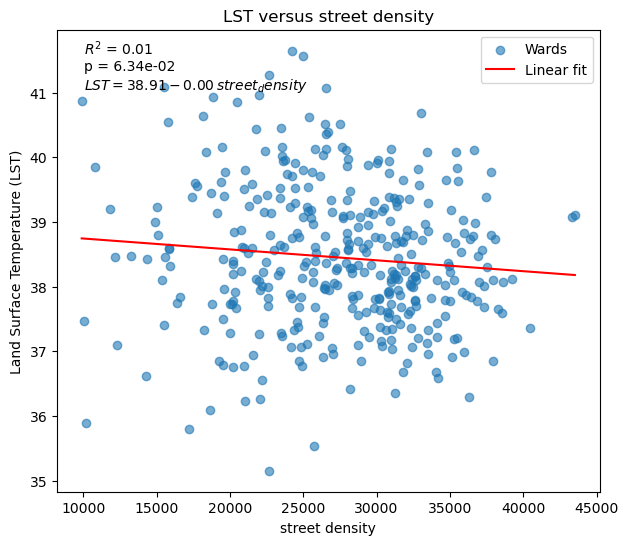

In [19]:
# x and y
x = merged["street_density"]
y = merged["mean_lst"]

# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("street density")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus street density")
plt.legend()

# annotation
plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST = {intercept:.2f}{slope:.2f}\\,street_density$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()


In [20]:
p_value

np.float64(0.06337099009424994)

In [21]:
print(slope, intercept, r_value)

-1.6852510639437117e-05 38.91205173312446 -0.09675108152985562


In [22]:
pearsonr(merged['street_density'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(-0.09675108152985558), pvalue=np.float64(0.06337099009424997))

In [23]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['street_density']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     3.468
Date:                Wed, 14 Jan 2026   Prob (F-statistic):             0.0634
Time:                        22:45:31   Log-Likelihood:                -555.68
No. Observations:                 369   AIC:                             1115.
Df Residuals:                     367   BIC:                             1123.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             38.9121      0.254    152.

In [24]:
pearsonr(merged['street_density'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(-0.09675108152985558), pvalue=np.float64(0.06337099009424997))

#### Straightness

In [25]:
straightness_path = PROCESSED_DIR /'results_bangalore_straightness_all_roads.csv'
df_straightness = pd.read_csv(straightness_path)

In [26]:
df_straightness.head()

,Unnamed: 0,ward_id,ward_name,Corporatio,straightness
0,0,25,25 - Vinayaka Layout,West,0.722825
1,1,2,2 - Aerocity,North,0.644505
2,2,3,3 - Chowdeshwari ward,North,0.681202
3,3,15,15 - Ramamurthy Nagara,East,0.697888
4,4,58,58 - Nagashettyhalli,North,0.666402


In [27]:
merged = pd.merge(merged, df_straightness, on='ward_name')
merged.head()

,ward_name,mean_lst,ward_id_x,Corporation,street_length,street_density,area,Unnamed: 0,ward_id_y,Corporatio,straightness
0,24 - Agaram,37.101195,24,Central,135628.586924,12281.620334,1.104322e+07,7,24,Central,0.664071
1,11 - Old Baiyappanahalli,38.345464,11,Central,11072.345249,20184.036462,5.485694e+05,9,11,Central,0.701827
2,41 - V.V Puram,38.115046,41,Central,42281.858139,39226.496243,1.077890e+06,21,41,Central,0.796102
3,51 - Old Guddadahalli,39.383769,51,Central,7924.842106,37447.552097,2.116251e+05,26,51,Central,0.756479
4,13 - Krishnaiahnapalya,37.982895,13,Central,31325.489794,26383.779772,1.187301e+06,46,13,Central,0.604820


In [28]:
merged = merged[['ward_name', 'mean_lst', 'ward_id_x', 'Corporation', 'street_length', 'street_density', 'area', 'straightness']]
merged.head()

,ward_name,mean_lst,ward_id_x,Corporation,street_length,street_density,area,straightness
0,24 - Agaram,37.101195,24,Central,135628.586924,12281.620334,1.104322e+07,0.664071
1,11 - Old Baiyappanahalli,38.345464,11,Central,11072.345249,20184.036462,5.485694e+05,0.701827
2,41 - V.V Puram,38.115046,41,Central,42281.858139,39226.496243,1.077890e+06,0.796102
3,51 - Old Guddadahalli,39.383769,51,Central,7924.842106,37447.552097,2.116251e+05,0.756479
4,13 - Krishnaiahnapalya,37.982895,13,Central,31325.489794,26383.779772,1.187301e+06,0.604820


In [29]:
# Rename the columns
merged = merged.rename(columns={
    'ward_id_x': 'ward_id',
})
merged.head()

,ward_name,mean_lst,ward_id,Corporation,street_length,street_density,area,straightness
0,24 - Agaram,37.101195,24,Central,135628.586924,12281.620334,1.104322e+07,0.664071
1,11 - Old Baiyappanahalli,38.345464,11,Central,11072.345249,20184.036462,5.485694e+05,0.701827
2,41 - V.V Puram,38.115046,41,Central,42281.858139,39226.496243,1.077890e+06,0.796102
3,51 - Old Guddadahalli,39.383769,51,Central,7924.842106,37447.552097,2.116251e+05,0.756479
4,13 - Krishnaiahnapalya,37.982895,13,Central,31325.489794,26383.779772,1.187301e+06,0.604820


In [30]:
# x and y
x = merged["straightness"]
y = merged["mean_lst"]

In [31]:
fig_path = IMAGES_DIR / 'regression_bangalore_straightness_ermida.png'

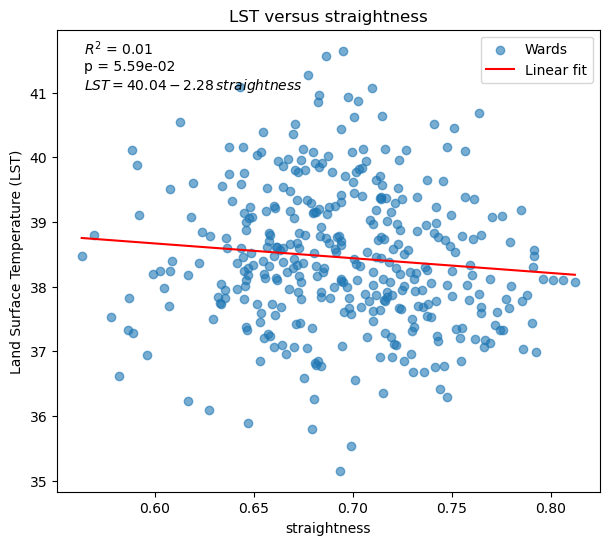

In [32]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("straightness")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus straightness")
plt.legend()

# annotation

plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST = {intercept:.2f}{slope:.2f}\\,straightness$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [33]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['straightness']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     3.679
Date:                Wed, 14 Jan 2026   Prob (F-statistic):             0.0559
Time:                        22:47:57   Log-Likelihood:                -555.57
No. Observations:                 369   AIC:                             1115.
Df Residuals:                     367   BIC:                             1123.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           40.0371      0.829     48.284   

In [34]:
pearsonr(merged['straightness'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(-0.09962929748442725), pvalue=np.float64(0.0558655766991816))

#### Global closeness

In [35]:
global_closeness_path = PROCESSED_DIR /'results_bangalore_global_closeness_all_roads.csv'
df_global_closeness = pd.read_csv(global_closeness_path)

In [36]:
df_global_closeness.head()

,Unnamed: 0,ward_id,ward_name,Corporatio,closeness
0,0,25,25 - Vinayaka Layout,West,0.000769
1,1,2,2 - Aerocity,North,0.000296
2,2,3,3 - Chowdeshwari ward,North,0.000380
3,3,15,15 - Ramamurthy Nagara,East,0.001307
4,4,58,58 - Nagashettyhalli,North,0.001277


In [37]:
merged = pd.merge(merged, df_global_closeness, on='ward_name')
merged.head()

,ward_name,mean_lst,ward_id_x,Corporation,street_length,street_density,area,straightness,Unnamed: 0,ward_id_y,Corporatio,closeness
0,24 - Agaram,37.101195,24,Central,135628.586924,12281.620334,1.104322e+07,0.664071,7,24,Central,0.000244
1,11 - Old Baiyappanahalli,38.345464,11,Central,11072.345249,20184.036462,5.485694e+05,0.701827,9,11,Central,0.001638
2,41 - V.V Puram,38.115046,41,Central,42281.858139,39226.496243,1.077890e+06,0.796102,21,41,Central,0.001257
3,51 - Old Guddadahalli,39.383769,51,Central,7924.842106,37447.552097,2.116251e+05,0.756479,26,51,Central,0.002735
4,13 - Krishnaiahnapalya,37.982895,13,Central,31325.489794,26383.779772,1.187301e+06,0.604820,46,13,Central,0.000615


In [38]:
merged = merged[['ward_name', 'mean_lst', 'ward_id_x', 'Corporation', 'street_length', 'street_density', 'area', 'straightness', 'closeness']]
merged.head()

,ward_name,mean_lst,ward_id_x,Corporation,street_length,street_density,area,straightness,closeness
0,24 - Agaram,37.101195,24,Central,135628.586924,12281.620334,1.104322e+07,0.664071,0.000244
1,11 - Old Baiyappanahalli,38.345464,11,Central,11072.345249,20184.036462,5.485694e+05,0.701827,0.001638
2,41 - V.V Puram,38.115046,41,Central,42281.858139,39226.496243,1.077890e+06,0.796102,0.001257
3,51 - Old Guddadahalli,39.383769,51,Central,7924.842106,37447.552097,2.116251e+05,0.756479,0.002735
4,13 - Krishnaiahnapalya,37.982895,13,Central,31325.489794,26383.779772,1.187301e+06,0.604820,0.000615


In [39]:
# Rename the columns
merged = merged.rename(columns={
    'ward_id_x': 'ward_id',
    'closeness': 'global_closeness'
})
merged.head()

,ward_name,mean_lst,ward_id,Corporation,street_length,street_density,area,straightness,global_closeness
0,24 - Agaram,37.101195,24,Central,135628.586924,12281.620334,1.104322e+07,0.664071,0.000244
1,11 - Old Baiyappanahalli,38.345464,11,Central,11072.345249,20184.036462,5.485694e+05,0.701827,0.001638
2,41 - V.V Puram,38.115046,41,Central,42281.858139,39226.496243,1.077890e+06,0.796102,0.001257
3,51 - Old Guddadahalli,39.383769,51,Central,7924.842106,37447.552097,2.116251e+05,0.756479,0.002735
4,13 - Krishnaiahnapalya,37.982895,13,Central,31325.489794,26383.779772,1.187301e+06,0.604820,0.000615


In [40]:
# x and y
x = merged["global_closeness"]
y = merged["mean_lst"]

In [41]:
# plot
# plt.figure(figsize=(7, 6))
# plt.scatter(x, y, alpha=0.6, label="Pixels")

In [42]:
fig_path = IMAGES_DIR / 'regression_bangalore_global_closeness_ermida.png'

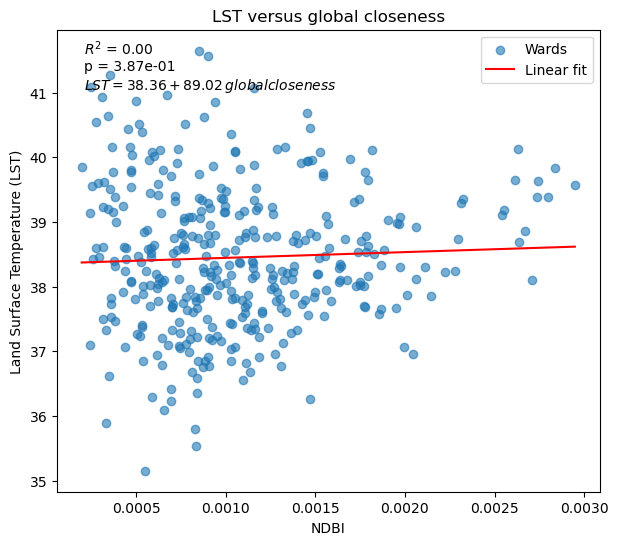

In [43]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("NDBI")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus global closeness")
plt.legend()

# annotation

plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST  = {intercept:.2f} + {slope:.2f}\\,global closeness$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [44]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['global_closeness']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7504
Date:                Wed, 14 Jan 2026   Prob (F-statistic):              0.387
Time:                        22:48:54   Log-Likelihood:                -557.03
No. Observations:                 369   AIC:                             1118.
Df Residuals:                     367   BIC:                             1126.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               38.3550      0.124  

In [45]:
pearsonr(merged['global_closeness'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.045172147862851675), pvalue=np.float64(0.38691458579179994))

#### Local closeness

In [46]:
local_closeness_path = PROCESSED_DIR /'results_bangalore_local_closeness_all_roads.csv'
df_local_closeness = pd.read_csv(local_closeness_path)
df_local_closeness.head()

,Unnamed: 0,ward_id,ward_name,Corporatio,closeness_local
0,0,25,25 - Vinayaka Layout,West,0.000321
1,1,2,2 - Aerocity,North,0.000146
2,2,3,3 - Chowdeshwari ward,North,0.000185
3,3,15,15 - Ramamurthy Nagara,East,0.000882
4,4,58,58 - Nagashettyhalli,North,0.000796


In [47]:
merged = pd.merge(merged, df_local_closeness, on='ward_name')
merged.head()

,ward_name,mean_lst,ward_id_x,Corporation,street_length,street_density,area,straightness,global_closeness,Unnamed: 0,ward_id_y,Corporatio,closeness_local
0,24 - Agaram,37.101195,24,Central,135628.586924,12281.620334,1.104322e+07,0.664071,0.000244,7,24,Central,0.000122
1,11 - Old Baiyappanahalli,38.345464,11,Central,11072.345249,20184.036462,5.485694e+05,0.701827,0.001638,9,11,Central,0.001547
2,41 - V.V Puram,38.115046,41,Central,42281.858139,39226.496243,1.077890e+06,0.796102,0.001257,21,41,Central,0.000792
3,51 - Old Guddadahalli,39.383769,51,Central,7924.842106,37447.552097,2.116251e+05,0.756479,0.002735,26,51,Central,0.002609
4,13 - Krishnaiahnapalya,37.982895,13,Central,31325.489794,26383.779772,1.187301e+06,0.604820,0.000615,46,13,Central,0.000530


In [48]:
merged = merged[['ward_name', 'mean_lst', 'ward_id_x', 'Corporation', 'street_length', 'street_density', 'area', 'straightness', 'global_closeness', 'closeness_local']]
merged.head()

,ward_name,mean_lst,ward_id_x,Corporation,street_length,street_density,area,straightness,global_closeness,closeness_local
0,24 - Agaram,37.101195,24,Central,135628.586924,12281.620334,1.104322e+07,0.664071,0.000244,0.000122
1,11 - Old Baiyappanahalli,38.345464,11,Central,11072.345249,20184.036462,5.485694e+05,0.701827,0.001638,0.001547
2,41 - V.V Puram,38.115046,41,Central,42281.858139,39226.496243,1.077890e+06,0.796102,0.001257,0.000792
3,51 - Old Guddadahalli,39.383769,51,Central,7924.842106,37447.552097,2.116251e+05,0.756479,0.002735,0.002609
4,13 - Krishnaiahnapalya,37.982895,13,Central,31325.489794,26383.779772,1.187301e+06,0.604820,0.000615,0.000530


In [49]:
# Rename the columns
merged = merged.rename(columns={
    'ward_id_x': 'ward_id',
    #'closeness': 'global closeness',
    'closeness_local': 'local_closeness'
})
merged.head()

,ward_name,mean_lst,ward_id,Corporation,street_length,street_density,area,straightness,global_closeness,local_closeness
0,24 - Agaram,37.101195,24,Central,135628.586924,12281.620334,1.104322e+07,0.664071,0.000244,0.000122
1,11 - Old Baiyappanahalli,38.345464,11,Central,11072.345249,20184.036462,5.485694e+05,0.701827,0.001638,0.001547
2,41 - V.V Puram,38.115046,41,Central,42281.858139,39226.496243,1.077890e+06,0.796102,0.001257,0.000792
3,51 - Old Guddadahalli,39.383769,51,Central,7924.842106,37447.552097,2.116251e+05,0.756479,0.002735,0.002609
4,13 - Krishnaiahnapalya,37.982895,13,Central,31325.489794,26383.779772,1.187301e+06,0.604820,0.000615,0.000530


In [50]:
# x and y
x = merged["local_closeness"]
y = merged["mean_lst"]

In [96]:
# plot
# plt.figure(figsize=(7, 6))
# plt.scatter(x, y, alpha=0.6, label="Pixels")

In [51]:
fig_path = IMAGES_DIR / 'regression_bangalore_local_closeness_ermida.png'

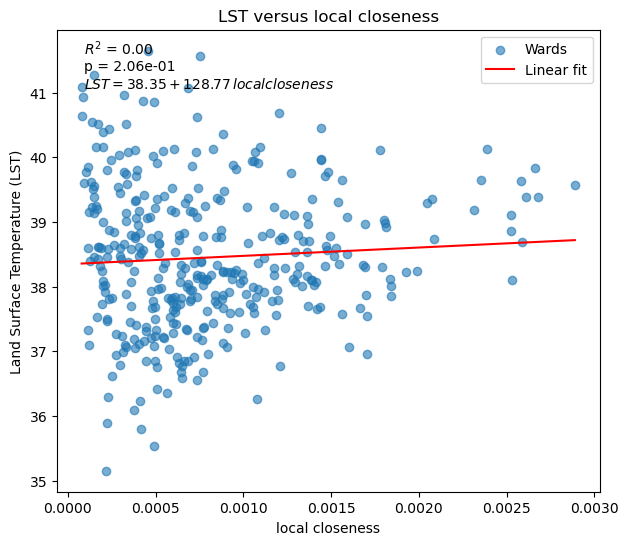

In [52]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("local closeness")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus local closeness")
plt.legend()


# annotation


plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST  = {intercept:.2f} + {slope:.2f}\\,local closeness$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [53]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['local_closeness']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.602
Date:                Wed, 14 Jan 2026   Prob (F-statistic):              0.206
Time:                        22:49:34   Log-Likelihood:                -556.61
No. Observations:                 369   AIC:                             1117.
Df Residuals:                     367   BIC:                             1125.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              38.3463      0.100    3

In [54]:
pearsonr(merged['local_closeness'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.06592487711797046), pvalue=np.float64(0.20642615093029304))

In [55]:
merged

,ward_name,mean_lst,ward_id,Corporation,street_length,street_density,area,straightness,global_closeness,local_closeness
0,24 - Agaram,37.101195,24,Central,135628.586924,12281.620334,1.104322e+07,0.664071,0.000244,0.000122
1,11 - Old Baiyappanahalli,38.345464,11,Central,11072.345249,20184.036462,5.485694e+05,0.701827,0.001638,0.001547
2,41 - V.V Puram,38.115046,41,Central,42281.858139,39226.496243,1.077890e+06,0.796102,0.001257,0.000792
3,51 - Old Guddadahalli,39.383769,51,Central,7924.842106,37447.552097,2.116251e+05,0.756479,0.002735,0.002609
4,13 - Krishnaiahnapalya,37.982895,13,Central,31325.489794,26383.779772,1.187301e+06,0.604820,0.000615,0.000530
...,...,...,...,...,...,...,...,...,...,...
364,47 - Vrishabhavathi Nagar,40.088257,47,West,20905.537281,35406.572312,5.904423e+05,0.699408,0.001528,0.001065
365,98 - Ashoka Nagara,38.217841,98,West,18651.660359,25687.739453,7.260919e+05,0.728873,0.000877,0.000885
366,8 - Hegganahalli,40.618568,8,West,22376.806818,25402.238351,8.808990e+05,0.700411,0.000878,0.000738
367,50 - Sadashiva Nagara,35.151538,50,West,112807.710820,22698.084413,4.969922e+06,0.693499,0.000548,0.000216


## Correlation

In [56]:
vars_df = merged[[
    "mean_lst",
    "street_density",
    "straightness",
    "global_closeness",
    "local_closeness"
]].dropna()

In [58]:
corr = vars_df.corr(method="pearson")

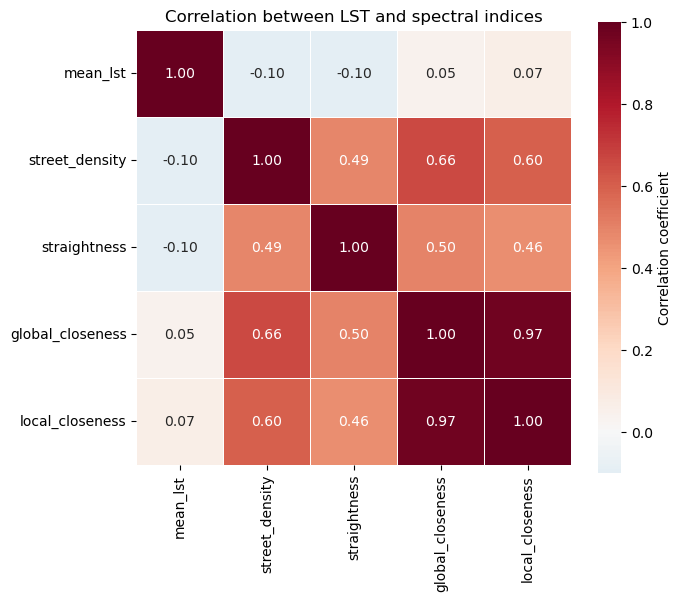

In [59]:
corr_path_indices = IMAGES_DIR / 'corr_indices_bangalore_ermida.png'
plt.figure(figsize=(7, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation coefficient"}
)

plt.title("Correlation between LST and spectral indices")
plt.tight_layout()
plt.savefig(corr_path_indices, dpi=300, bbox_inches="tight")
plt.show()